In [1]:
import polars as pl, pymc as pm, arviz as az, numpy as np, pandas as pd, xarray as xr

In [2]:
df = pl.read_csv("../../Rethinking_2/End_of_chapter_problems/data/foxes.csv", separator=";")

In [3]:
def standardize(df, cols):
    return df.with_columns((pl.col(*cols) - pl.col(*cols).mean()) / pl.col(*cols).std())

df_standardized = standardize(df, cols=["avgfood", "groupsize", "area", "weight"])

In [4]:
with pm.Model() as all_model:
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta = pm.Normal("beta", mu=0, sigma=1, shape=3)

    mu = alpha + beta[0]*df['avgfood'].to_numpy() + beta[1]*df["groupsize"].to_numpy() + beta[2]*df['area'].to_numpy()
    sigma = pm.LogNormal("sigma", mu=0, sigma=1)

    weight = pm.Normal("weight", mu=mu, sigma=sigma, observed=df['weight'].to_numpy())

    first_prior_predictive = pm.sample_prior_predictive(draws=500)

    first_posterior_predictive = pm.sample(chains=4, draws=500)

    pm.compute_log_likelihood(first_posterior_predictive)


with pm.Model() as avgfood_groupsize_model:
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta = pm.Normal("beta", mu=0, sigma=1, shape=2)

    mu = alpha + beta[0]*df['avgfood'].to_numpy() + beta[1]*df["groupsize"].to_numpy()
    sigma = pm.LogNormal("sigma", mu=0, sigma=1)

    weight = pm.Normal("weight", mu=mu, sigma=sigma, observed=df['weight'].to_numpy())

    second_prior_predictive = pm.sample_prior_predictive(draws=500)

    second_posterior_predictive = pm.sample(chains=4, draws=500)

    pm.compute_log_likelihood(second_posterior_predictive)


with pm.Model() as groupsize_area_model:
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta = pm.Normal("beta", mu=0, sigma=1, shape=2)

    mu = alpha + beta[0]*df["groupsize"].to_numpy() + beta[1]*df['area'].to_numpy()
    sigma = pm.LogNormal("sigma", mu=0, sigma=1)

    weight = pm.Normal("weight", mu=mu, sigma=sigma, observed=df['weight'].to_numpy())

    third_prior_predictive = pm.sample_prior_predictive(draws=500)

    third_posterior_predictive = pm.sample(chains=4, draws=500)

    pm.compute_log_likelihood(third_posterior_predictive)



with pm.Model() as avgfood_model:
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta = pm.Normal("beta", mu=0, sigma=1)

    mu = alpha + beta*df['avgfood'].to_numpy()
    sigma = pm.LogNormal("sigma", mu=0, sigma=1)

    weight = pm.Normal("weight", mu=mu, sigma=sigma, observed=df['weight'].to_numpy())

    fourth_prior_predictive = pm.sample_prior_predictive(draws=500)

    fourth_posterior_predictive = pm.sample(chains=4, draws=500)

    pm.compute_log_likelihood(fourth_posterior_predictive)

with pm.Model() as area_model:
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta = pm.Normal("beta", mu=0, sigma=1)

    mu = alpha + beta*df['area'].to_numpy()
    sigma = pm.LogNormal("sigma", mu=0, sigma=1)

    weight = pm.Normal("weight", mu=mu, sigma=sigma, observed=df['weight'].to_numpy())

    fifth_prior_predictive = pm.sample_prior_predictive(draws=500)

    fifth_posterior_predictive = pm.sample(chains=4, draws=500)

    pm.compute_log_likelihood(fifth_posterior_predictive)

WARNING (pytensor.link.c.cmodule): Deleting (Broken cache directory [EOF]): /Users/voutrata/.pytensor/compiledir_macOS-26.2-arm64-arm-64bit-arm-3.10.4-64/tmp9awao23f
Sampling: [alpha, beta, sigma, weight]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 1 seconds.


Output()

Sampling: [alpha, beta, sigma, weight]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


...

Output()

Sampling: [alpha, beta, sigma, weight]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 1 seconds.


Output()

In [5]:
comparison = az.compare({
    "all_model": first_posterior_predictive,
    "avgfood_groupsize_model": second_posterior_predictive,
    "groupsize_area_model": third_posterior_predictive,
    "avgfood_model": fourth_posterior_predictive,
    "area_model": fifth_posterior_predictive,
}, scale="deviance", ic="waic")
comparison

/Users/voutrata/Projects/pymc-resources/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/Users/voutrata/Projects/pymc-resources/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
all_model,0,363.212169,3.920919,0.000000,4.999090e-01,15.397835,0.000000,True,deviance
groupsize_area_model,1,364.668679,3.548926,1.456510,1.167130e-01,15.305618,1.842727,True,deviance
avgfood_groupsize_model,2,365.214683,3.195823,2.002514,3.833780e-01,14.433089,5.969203,False,deviance
avgfood_model,3,374.632551,2.259742,11.420382,0.000000e+00,13.015140,7.683366,False,deviance
area_model,4,375.355822,2.607792,12.143653,1.776357e-15,13.125083,7.019338,False,deviance


<Axes: title={'center': 'Model comparison\nlower is better'}, xlabel='elpd_waic (deviance)', ylabel='ranked models'>

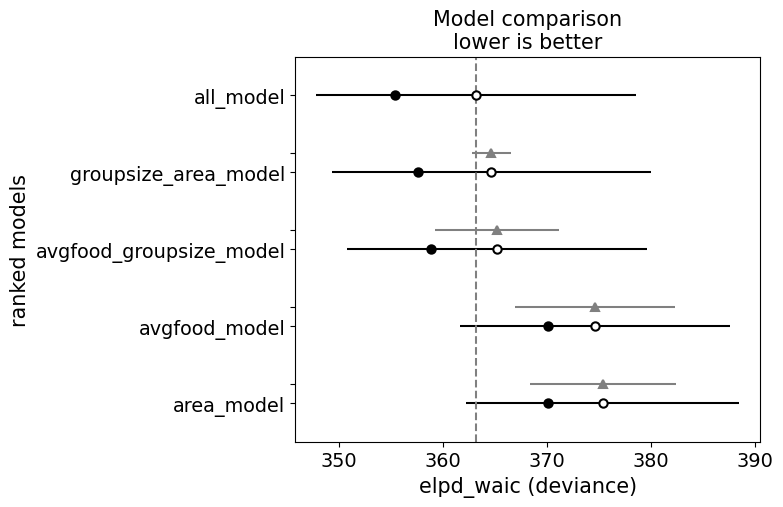

In [6]:
az.plot_compare(comparison, insample_dev=True, plot_ic_diff=True)